# Fairness Mitigation and Before/After Comparison

**TrustAI Internship — Task 3** · Osman Eren Doğan

Task 1 showed the classifier fails all three fairness metrics on **age**. Here three simple
mitigations are applied to that same model and dataset, and the fairness *and* performance
consequences are compared before and after.

This notebook **presents** results. Produce them first:

```bash
python ../src/mitigation.py
```

## Why age?

Age is a **legally protected class** in credit lending (e.g. under the US Equal Credit
Opportunity Act), and the Task 1 baseline fails all three metrics on it — demographic parity
−0.253, equal opportunity −0.165, disparate impact 0.642. Education and home ownership are
audited too, but they are not protected classes in the same sense; they act as proxies.

## The three methods

| | Method | Idea |
|---|---|---|
| **A** | Remove sensitive + proxy features | Stop the model seeing age at all — "fairness through unawareness" |
| **B** | Group-specific threshold | One model, but a young applicant must look riskier before being rejected |
| **C** | Sample reweighting | Reweight training rows so group and outcome look independent (Kamiran & Calders) |

**Method note.** Every variant is trained and evaluated on the *identical* train/test rows, so
the comparison isolates the mitigation. The threshold in B is tuned on **out-of-fold predictions
from the training set** — never on the test set — and targets a disparate impact of 0.82 rather
than 0.80, leaving a margin for sampling noise.


In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

RESULTS = Path("results")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

fairness = pd.read_csv(RESULTS / "before_after_fairness.csv")
performance = pd.read_csv(RESULTS / "before_after_performance.csv")
print((RESULTS / "mitigation_notes.txt").read_text())

A: dropped age plus its 3 strongest proxies ['subscription_count', 'online_shopping_frequency', 'owns_car']
B: protected-group threshold 0.63 (tuned out of fold for DI >= 0.82); reference stays 0.5
C: reweighting, weight range 0.657 to 1.228


## 1. Fairness before and after — the age axis

In [2]:
age = fairness[fairness["attribute"] == "age"][[
    "variant", "approval_rate_protected", "approval_rate_reference",
    "demographic_parity_difference", "equal_opportunity_difference",
    "disparate_impact_ratio",
]].set_index("variant")
age

,approval_rate_protected,approval_rate_reference,demographic_parity_difference,equal_opportunity_difference,disparate_impact_ratio
variant,,,,,
baseline,0.4545,0.7078,-0.2532,-0.1647,0.6422
A: remove age+proxies,0.5017,0.7072,-0.2056,-0.0959,0.7093
B: group threshold,0.5821,0.7078,-0.1257,-0.0310,0.8224
C: reweighting,0.5504,0.6976,-0.1471,-0.0351,0.7891


**Reading the table.** The protected group is young applicants (< 30); the reference group is
30+.

* **Disparate impact** rises from 0.642 to 0.709 (A), 0.822 (B) and 0.789 (C). **Only method B
  clears the 0.80 legal threshold.** C comes within one point of it.
* **Equal opportunity** — the merit-aware metric — improves dramatically everywhere: −0.165
  becomes −0.096, −0.031 and −0.035. All three methods pass the ±0.10 rule of thumb, meaning
  young applicants who *genuinely repay* are now approved at nearly the same rate as older ones.
* **Demographic parity** never passes. Even the best variant leaves a 12.6-point gap. That is
  expected: young applicants really do default more often (39.9 % vs 23.2 %), and demographic
  parity refuses to allow for that.

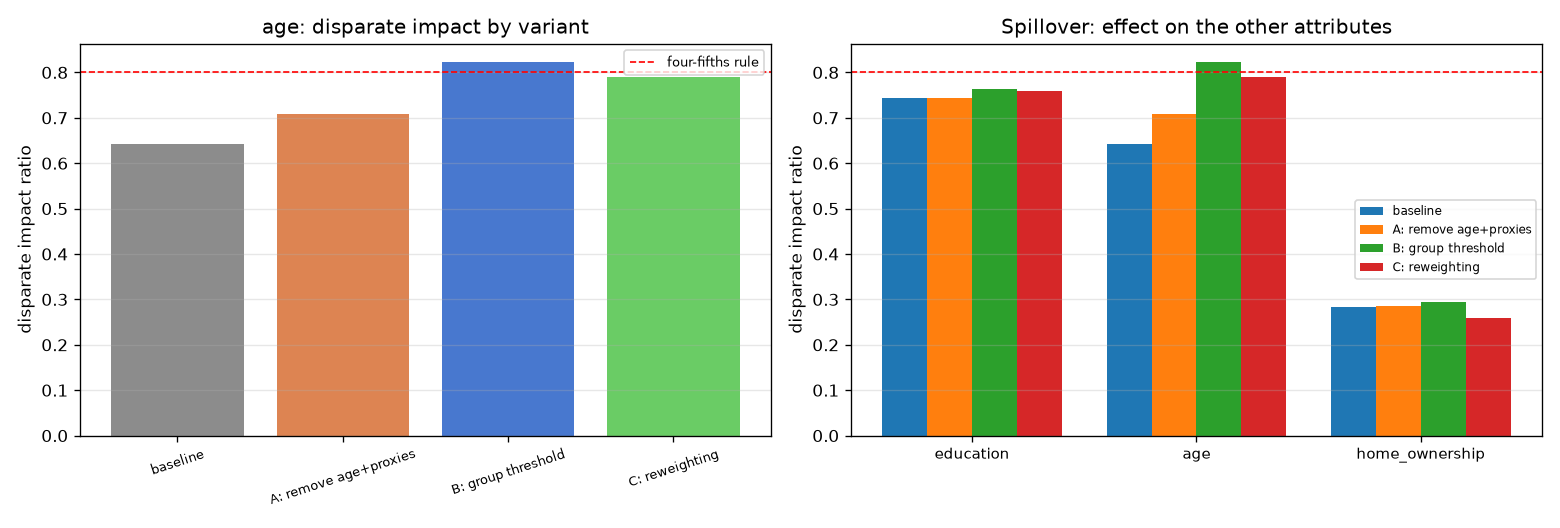

In [3]:
display(Image(filename=str(RESULTS / "fig_before_after.png")))

## 2. What it costs

In [4]:
performance.set_index("variant")

,roc_auc,accuracy,recall_delinquency,precision_delinquency,defaulters_approved_FN,good_payers_rejected_FP,approval_rate
variant,,,,,,,
baseline,0.9136,0.8587,0.8753,0.6787,654,2173,0.6618
A: remove age+proxies,0.9146,0.8651,0.8723,0.6930,670,2027,0.6699
B: group threshold,0.9136,0.8648,0.8429,0.7016,824,1880,0.6849
C: reweighting,0.9123,0.8598,0.8602,0.6854,733,2071,0.6708


**The trade-off is smaller than expected — but it is not zero.**

* **A (remove age + proxies)** is close to free: ROC AUC actually *rises* slightly
  (0.9136 → 0.9146) and only 16 more defaulters get approved. Dropping the three age proxies
  removed noise as well as signal. But it only moves disparate impact to 0.709 — still failing.
* **B (group threshold)** is the only variant that satisfies the law, and it costs the most:
  recall on delinquency falls 0.875 → 0.843 and **170 more defaulters are approved** (654 → 824).
  In a real loan book each one is a direct credit loss. ROC AUC is unchanged because the model
  is the same — only the decision rule moved.
* **C (reweighting)** sits in between: 79 extra approved defaulters, disparate impact 0.789.

Note that **accuracy rises for every variant**. That is not a fairness bonus — it is an artifact
of `class_weight="balanced"` over-flagging risk at threshold 0.5 (2,173 good payers rejected vs
654 defaulters approved). The decision-relevant costs are recall and the approved-defaulter
count, and both get worse under B and C.

## 3. Does fixing age fix anything else?

In [5]:
spillover = fairness.pivot(index="attribute", columns="variant",
                           values="disparate_impact_ratio")
spillover = spillover[["baseline", "A: remove age+proxies", "B: group threshold", "C: reweighting"]]
spillover

variant,baseline,A: remove age+proxies,B: group threshold,C: reweighting
attribute,,,,
age,0.6422,0.7093,0.8224,0.7891
education,0.7440,0.7442,0.7632,0.7587
home_ownership,0.2828,0.2853,0.2937,0.2593


**No.** Education stays at roughly 0.744–0.763 and home ownership at 0.259–0.294 across every
variant. Mitigating one attribute does essentially nothing for the others — **home ownership
remains at about a third of the legal threshold under all three methods.**

This matters for governance: a model cannot be declared "fixed" because one protected attribute
was remediated. Each attribute needs its own assessment.

## 4. Recommendation

**Method B (group-specific threshold) is the only one that makes the age axis legally
compliant**, and it does so with a quantified cost of 170 additional approved defaulters per
20,000 applications. Method C achieves most of the fairness gain for roughly half the cost but
stops just short of the 0.80 line. Method A is almost free and should be adopted regardless —
it improves fairness *and* accuracy slightly — but it is not sufficient on its own.

**Suggested combination:** apply A permanently (it costs nothing), and layer B on top if the
business accepts the credit-loss trade-off. That is the only route to a compliant age axis in
this experiment.

### Important caveat: group-specific thresholds are disparate treatment

Method B uses the protected attribute **directly in the decision rule** — a young applicant and
an older applicant with the same risk score receive different decisions. Even though the
*outcome* is fairer, this is **disparate treatment**, which is itself legally problematic in
credit (ECOA prohibits it). A production system should prefer methods that do not condition the
decision on the protected attribute, such as reject-option classification around the decision
boundary, or calibrated equalized-odds post-processing.

Method C (reweighting) has no such problem — it only changes how the model is trained, not how
decisions are made — which is why it is worth pursuing further despite falling just short here.

### Limitations

1. The data is **synthetic**; every number describes this model and dataset, not real applicants.
2. Only the age axis was mitigated. Home ownership remains severely unfair under all variants.
3. Demographic parity is not achievable here without a much larger recall sacrifice, because the
   groups genuinely default at different rates.
4. All variants are evaluated at a single decision threshold for the reference group (0.5).
